# Data Preparation Notebook — Module 1
### AI Chatbot for Internal Helpdesk (Project-04)

This notebook walks through **Module 1: Complete Dataset Preparation, Domain
Adaptation and Validation**. It performs the same pipeline as
`src/prepare_dataset.py`:

1. Module 1 Overview
2. Load Raw Datasets
3. Inspect Dataset Structure
4. Missing Value Analysis
5. Duplicate Analysis
6. Intent Distribution
7. Internal Helpdesk Domain Analysis
8. Data Cleaning
9. Intent Normalization
10. Intent Balancing
11. Entity Validation
12. Final Dataset Validation
13. Dataset Statistics
14. Visualizations
15. Save Processed Dataset
16. Final Quality Gate


## 1. Module 1 Overview

### Objective
Produce a clean, validated, reproducible **internal helpdesk FAQ dataset**
suitable for Module 2 (NLP preprocessing), Module 3 (intent classification)
and Module 4 (chatbot engine).

### Inputs
- **Bitext dataset** (`data/raw/Bitext_...csv`) — original source, 26,872
  e-commerce records. Never modified.
- **`data/raw/faq_dataset.csv`** — project internal-helpdesk candidate,
  159 records, 22 intents. Clean but imbalanced.
- **`src/augmentation_data.py`** — 135 curated examples that bring every
  intent to >= 12 examples.

### Outputs
- `data/processed/faq_dataset.csv` — final clean dataset.
- `outputs/reports/dataset_report.txt` — data quality report.
- `outputs/charts/intent_distribution.png` + `intent_distribution_pie.png`.


In [1]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np

# Project root = the working directory for this notebook.
PROJECT_ROOT = Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from prepare_dataset import DatasetPreparation, REQUIRED_COLUMNS, \
    CANONICAL_INTENTS, CANONICAL_ENTITIES, AUGMENTED_DATA, \
    MIN_EXAMPLES_PER_INTENT

prep = DatasetPreparation(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("Required columns:", REQUIRED_COLUMNS)
print("Canonical intents:", len(CANONICAL_INTENTS), "| Canonical entities:", len(CANONICAL_ENTITIES))
print("Curated augmentation entries:", len(AUGMENTED_DATA))


Project root: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot
Required columns: ['question', 'intent', 'answer', 'entity']
Canonical intents: 22 | Canonical entities: 22
Curated augmentation entries: 135


## 2. Load Raw Datasets

In [2]:
# Bitext (original source) + base faq_dataset.csv + curated augmentation
bitext = prep.load_bitext_dataset()
raw = prep.load_raw_dataset()
aug = prep.load_augmented_data()

print("Bitext dataset       :", bitext.shape)
print("Base faq_dataset.csv :", raw.shape)
print("Curated augmentation :", aug.shape)


Bitext dataset       : (26872, 5)
Base faq_dataset.csv : (159, 4)
Curated augmentation : (135, 4)


In [3]:
raw.head()

,question,intent,answer,entity
0,How do I reset my password?,password_reset,You can reset your password through the intern...,password
1,I forgot my company password.,password_reset,Use the 'Forgot Password' link on the login pa...,password
2,Where can I change my password?,password_reset,You can change your password by going to Setti...,password
3,I cannot remember my login password.,password_reset,Click 'Forgot Password' on the login screen an...,password
4,How do I create a new password?,password_reset,"Log into the employee portal, navigate to Sett...",password


## 3. Inspect Dataset Structure

In [4]:
print("=== Bitext ===")
print("Columns:", list(bitext.columns))
print("N unique intents:", bitext["intent"].nunique())
print()
print("=== faq_dataset.csv ===")
print("Columns:", list(raw.columns))
print("dtypes:\n", raw.dtypes)
print()
print("=== Curated augmentation ===")
print("Columns:", list(aug.columns))
print("dtypes:\n", aug.dtypes)


=== Bitext ===
Columns: ['flags', 'instruction', 'category', 'intent', 'response']
N unique intents: 27

=== faq_dataset.csv ===
Columns: ['question', 'intent', 'answer', 'entity']
dtypes:
 question    object
intent      object
answer      object
entity      object
dtype: object

=== Curated augmentation ===
Columns: ['question', 'intent', 'answer', 'entity']
dtypes:
 question    object
intent      object
answer      object
entity      object
dtype: object


## 4. Missing Value Analysis

In [5]:
print("=== Bitext missing ===")
print(bitext.isna().sum().to_dict())
print()
print("=== faq_dataset.csv missing ===")
print(raw.isna().sum().to_dict())
print()
print("=== Augmentation missing ===")
print(aug.isna().sum().to_dict())


=== Bitext missing ===
{'flags': 0, 'instruction': 0, 'category': 0, 'intent': 0, 'response': 0}

=== faq_dataset.csv missing ===
{'question': 0, 'intent': 0, 'answer': 0, 'entity': 0}

=== Augmentation missing ===
{'question': 0, 'intent': 0, 'answer': 0, 'entity': 0}


In [6]:
for col in REQUIRED_COLUMNS:
    n_missing = raw[col].isna().sum()
    n_empty = (raw[col].astype(str).str.strip() == "").sum()
    print(f"{col}: NaN={n_missing}  empty=''={n_empty}")


question: NaN=0  empty=''=0
intent: NaN=0  empty=''=0
answer: NaN=0  empty=''=0
entity: NaN=0  empty=''=0


## 5. Duplicate Analysis

In [7]:
print("Bitext duplicate rows:", bitext.duplicated().sum())
print("Base duplicate rows  :", raw.duplicated().sum())
print("Base duplicate questions:", raw.duplicated(subset=["question"]).sum())
print("Augmentation duplicate questions:", aug.duplicated(subset=["question"]).sum())


Bitext duplicate rows: 0


Base duplicate rows  : 0
Base duplicate questions: 0
Augmentation duplicate questions: 0


## 6. Intent Distribution

In [8]:
base_dist = raw["intent"].value_counts()
print("Intent distribution in faq_dataset.csv (before balancing):")
print(base_dist.to_string())
print()
print("Intents below minimum (< 10):",
      sorted(base_dist[base_dist < MIN_EXAMPLES_PER_INTENT].index.tolist()))


Intent distribution in faq_dataset.csv (before balancing):
intent
password_reset           20
help                     20
laptop_problems          19
software_installation    17
email_problems           14
account_access           12
leave_policy             12
wifi_problems            11
goodbye                  10
greetings                10
salary_information        2
payroll                   2
internet_problems         1
working_hours             1
employee_id               1
holidays                  1
attendance                1
hr_support                1
security                  1
contact_information       1
office_location           1
technical_support         1

Intents below minimum (< 10): ['attendance', 'contact_information', 'employee_id', 'holidays', 'hr_support', 'internet_problems', 'office_location', 'payroll', 'salary_information', 'security', 'technical_support', 'working_hours']


## 7. Internal Helpdesk Domain Analysis

In [9]:
base_intents = set(raw["intent"].astype(str).str.strip())
not_canonical = base_intents - set(CANONICAL_INTENTS)
print("Base intents not in canonical set:", sorted(not_canonical) if not_canonical else "None")
required = set(CANONICAL_INTENTS)
print("Required intents:", len(required))
print("Present intents :", len(base_intents))
print("Missing intents :", sorted(required - base_intents) or "None")


Base intents not in canonical set: None
Required intents: 22
Present intents : 22
Missing intents : None


## 8. Data Cleaning

In [10]:
cleaned = prep.clean_questions(raw)
cleaned = prep.clean_answers(cleaned)
cleaned = prep.clean_entities(cleaned)
print("Records after cleaning:", len(cleaned))
print()
print("Sample clean question:", repr(cleaned["question"].iloc[0]))
print("Sample clean answer  :", repr(cleaned["answer"].iloc[0]))


Records after cleaning: 159

Sample clean question: 'How do I reset my password?'
Sample clean answer  : 'You can reset your password through the internal password reset portal at portal.company.com/reset. You will need your employee ID to verify your identity.'


## 9. Intent Normalization

In [11]:
cleaned = prep.normalize_intents(cleaned)
print("Intent normalization map:", prep.intent_normalization_map or "None")
print("Unique intents after normalization:", cleaned["intent"].nunique())
print("Intents present:", sorted(cleaned["intent"].unique()))


Intent normalization map: None
Unique intents after normalization: 22
Intents present: ['account_access', 'attendance', 'contact_information', 'email_problems', 'employee_id', 'goodbye', 'greetings', 'help', 'holidays', 'hr_support', 'internet_problems', 'laptop_problems', 'leave_policy', 'office_location', 'password_reset', 'payroll', 'salary_information', 'security', 'software_installation', 'technical_support', 'wifi_problems', 'working_hours']


## 10. Intent Balancing

In [12]:
# Combine cleaned base set with curated augmentation and dedupe.
combined = prep.combine(cleaned, aug)
combined = prep.fill_missing_entities(combined, aug)
combined = prep.clean_questions(combined)
combined = prep.clean_answers(combined)
combined = prep.clean_entities(combined)
combined = prep.remove_duplicates(combined)

dist = combined["intent"].value_counts()
print("Total records after balancing:", len(combined))
print()
print("Final intent distribution:")
print(dist.to_string())
print()
print("Min examples per intent:", int(dist.min()))
print("Intents below minimum:", prep.ensure_intent_balance(combined) or "None")


Total records after balancing: 294

Final intent distribution:
intent
password_reset           20
help                     20
laptop_problems          19
software_installation    17
email_problems           14
account_access           12
wifi_problems            12
internet_problems        12
attendance               12
leave_policy             12
holidays                 12
salary_information       12
payroll                  12
working_hours            12
employee_id              12
hr_support               12
contact_information      12
office_location          12
security                 12
technical_support        12
greetings                12
goodbye                  12

Min examples per intent: 12
Intents below minimum: None


## 11. Entity Validation

In [13]:
invalid_entities = prep.validate_entities(combined)
print("Invalid (non-canonical) entities:", invalid_entities or "None")
print()
ents = combined["entity"].astype(str).str.strip()
print("Entity counts (non-empty):")
print(ents[ents != ""].value_counts().to_string())


Invalid (non-canonical) entities: None

Entity counts (non-empty):
entity
password         20
help             20
laptop           19
software         17
email            14
account          12
wifi             12
internet         12
attendance       12
leave            12
holiday          12
salary           12
payroll          12
working_hours    12
employee_id      12
hr               12
contact          12
location         12
security         12
it_support       12
greeting         12
goodbye          12


## 12. Final Dataset Validation

In [14]:
validation = prep.validate_dataset(combined)
checks = {
    "columns present": validation["columns_present"],
    "not empty": validation["not_empty"],
    "no missing questions": validation["q_ok"],
    "no missing intents": validation["i_ok"],
    "no missing answers": validation["a_ok"],
    "no duplicate questions": validation["dup_ok"],
    "min 10 per intent": validation["balance_ok"],
    "intents valid": validation["intents_valid"],
    "entity validation": validation["entity_ok"],
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")


  [PASS] columns present
  [PASS] not empty
  [PASS] no missing questions
  [PASS] no missing intents
  [PASS] no missing answers
  [PASS] no duplicate questions
  [PASS] min 10 per intent
  [PASS] intents valid
  [PASS] entity validation


## 13. Dataset Statistics

In [15]:
stats = {
    "total_records": len(combined),
    "total_intents": combined["intent"].nunique(),
    "total_entities": combined["entity"].astype(str).str.strip().replace("", np.nan).dropna().nunique(),
    "missing_questions": validation["missing_questions"],
    "missing_intents": validation["missing_intents"],
    "missing_answers": validation["missing_answers"],
    "duplicate_questions": validation["duplicate_questions"],
    "min_per_intent": int(combined["intent"].value_counts().min()),
    "max_per_intent": int(combined["intent"].value_counts().max()),
    "avg_per_intent": round(float(combined["intent"].value_counts().mean()), 2),
}
for k, v in stats.items():
    print(f"{k}: {v}")


total_records: 294
total_intents: 22
total_entities: 22
missing_questions: 0
missing_intents: 0
missing_answers: 0
duplicate_questions: 0
min_per_intent: 12
max_per_intent: 20
avg_per_intent: 13.36


## 14. Visualizations

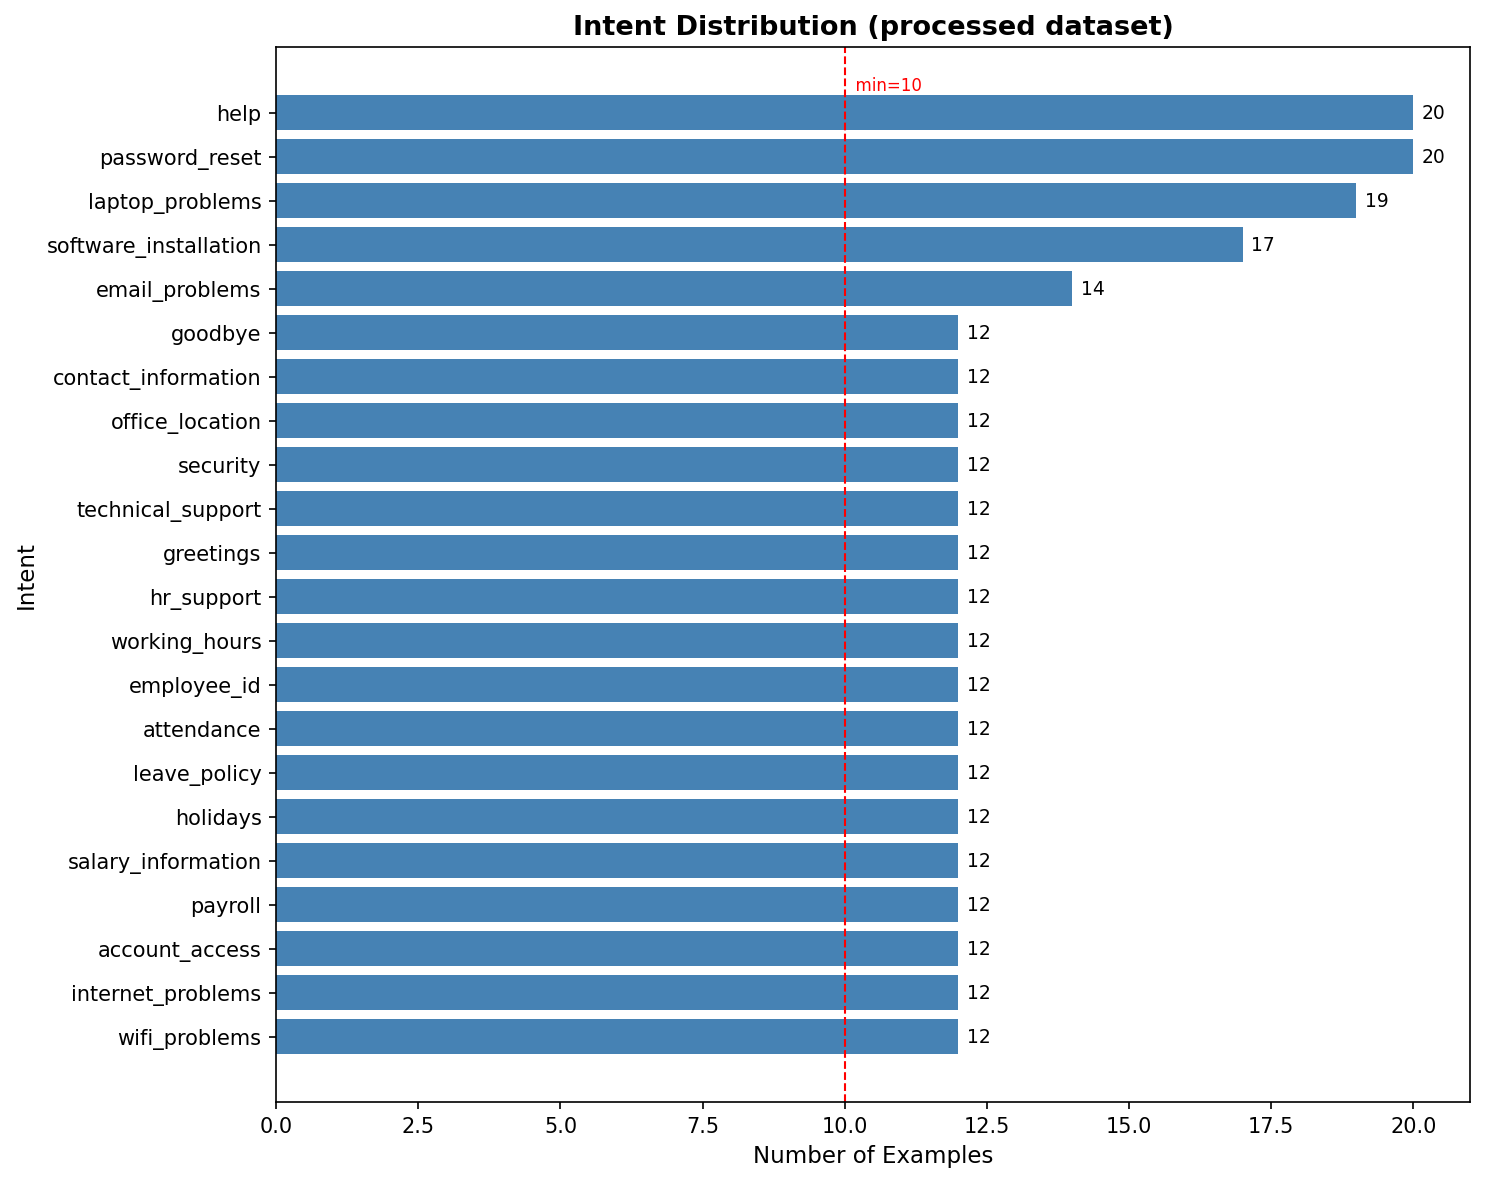

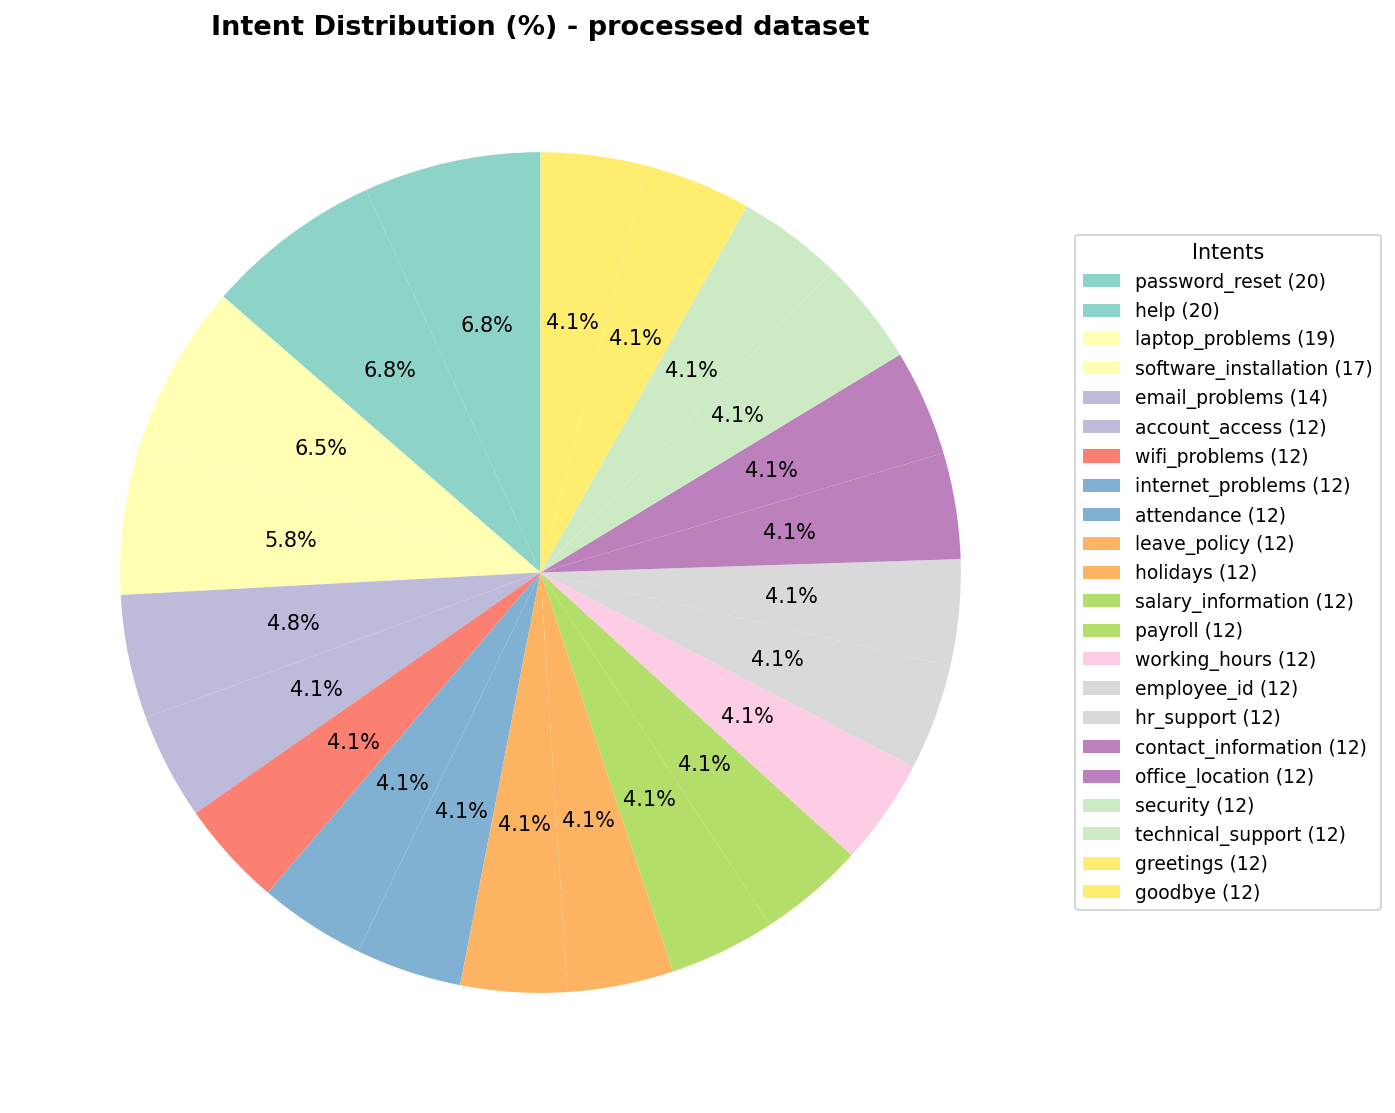

In [16]:
from IPython.display import Image, display
chart_paths = prep.generate_charts(combined)
for p in chart_paths:
    display(Image(filename=str(p)))


## 15. Save Processed Dataset

In [17]:
proc_path = prep.save_processed_dataset(combined)
aug_path = prep.save_augmented_raw_csv(aug)

print("Saved processed dataset  :", proc_path)
print("Saved augmented raw copy :", aug_path)

final = pd.read_csv(proc_path)
print("\nProcessed dataset shape:", final.shape)
print("Columns:", list(final.columns))


Saved processed dataset  : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\data\processed\faq_dataset.csv
Saved augmented raw copy : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\data\raw\faq_dataset_augmented.csv

Processed dataset shape: (294, 4)
Columns: ['question', 'intent', 'answer', 'entity']


## 16. Final Quality Gate

In [18]:
report_path = prep.generate_report(combined, raw, bitext, aug, validation)
print("Report written to:", report_path)

all_pass = all([
    validation["columns_present"], validation["not_empty"], validation["q_ok"],
    validation["i_ok"], validation["a_ok"], validation["dup_ok"],
    validation["balance_ok"], validation["intents_valid"],
    validation["entity_ok"],
])
print()
print("=" * 46)
print("MODULE 1: COMPLETE" if all_pass else "MODULE 1: NOT COMPLETE")
print("=" * 46)


Report written to: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\outputs\reports\dataset_report.txt

MODULE 1: COMPLETE
